In [9]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import heapq
import copy

**7.5 An Inventory Model**

Consider a shop that stocks a particular type of product that it sells for a price of r per unit. Customers demanding this product appear in accordance with a Poisson process with rate λ, and the amount demanded by each one is a random variable having distribution G. In order to meet demands, the shopkeeper must keep an amount of the product on hand, and whenever the on-hand inventory becomes low, additional units are ordered from the distributor. The shopkeeper uses a so-called (s, S) ordering policy; namely, whenever the on-hand inventory is less than s and there is no presently outstanding order, then an amount is ordered to bring it up to S, where s < S. That is, if the present inventory level is x and no order is outstanding, then if x < s the amount S − x is ordered. The cost of ordering y units of the product is a speciﬁed function c(y), and it takes L units of time until the order is delivered, with the payment being made upon delivery. In addition, the shop pays an inventory holding cost of h per unit item per unit time. Suppose further that whenever a customer demands more of the product than is presently available, then the amount on hand is sold and the remainder of the order is lost to the shop.

Let us see how we can use simulation to estimate the shop’s expected proﬁt up to some ﬁxed time T . To do so, we start by deﬁning the variables and events as follows.


In [65]:
class Product:
    def __init__(self, initial_inventory, sell_prices, holding_cost, lead_time, s, S, demand_function):
        # Initial Parameters
        self.initial_inventory_amount = initial_inventory
        self.sell_prices_per_unit = sell_prices
        self.holding_cost_per_unit = holding_cost
        self.lead_time = lead_time
        self.demand_function = demand_function
        self.S = S
        self.s = s
        
        self.reset_simulation_parameters()
        
    def reset_simulation_parameters(self):
        self.actual_inventory_amount = self.initial_inventory_amount
        
        self.total_inventory_holding_cost = 0
        self.total_order_amount = 0
        self.total_revenue = 0
        self.total_lost_amount = 0
    
    def charge_holding_cost(self, time):
        self.total_inventory_holding_cost += time * self.holding_cost_per_unit * self.actual_inventory_amount
    
    def get_revenue_and_losses(self, demand):
        w =  min(demand, self.actual_inventory_amount)
        self.total_revenue += w * self.sell_prices_per_unit
        self.total_lost_amount += (demand - w) * self.sell_prices_per_unit
        self.actual_inventory_amount -= w
       
    def summary(self):
        return {
        "holding cost": self.total_inventory_holding_cost,
        "order amaount": self.total_order_amount,
        "revenue": self.total_revenue,
        "lost amount": self.total_lost_amount,
        "net profit": self.total_revenue - self.total_inventory_holding_cost - self.total_order_amount
        }

In [66]:

class InventoryKStockSimulator:
    def __init__(self, customer_arrival_function, customer_demand_function, order_cost_function, 
                products: list["Product"], closing_time: int):
        
        # Parameters
        self.customer_arrival_function = customer_arrival_function
        self.customer_demand_function = customer_demand_function
        self.order_cost_function = order_cost_function
        self.products_list = products
        self.closing_time = closing_time
        
    
    def initialize_variables(self):
        # System State Variables
        for product in self.products_list:
            product.reset_simulation_parameters()
        
        # Events Variables
        self.time = 0
        self.events_queue = []
        self.actual_ordered_products = {i: False for i in range(len(self.products_list))}
        
    
    def process_customer(self, current_time):
        
        
        for product_id in self.customer_demand_function(len(self.products_list)):
            
            product = self.products_list[product_id]

            demand = product.demand_function()
            product.get_revenue_and_losses(demand)       
            
            if not self.actual_ordered_products[product_id] and product.actual_inventory_amount < product.s:
                amount = product.S - product.actual_inventory_amount
                heapq.heappush(self.events_queue, (current_time + product.lead_time, 'order', product_id, amount))
                self.actual_ordered_products[product_id] = True
            
        if self.time < self.closing_time:
            heapq.heappush(self.events_queue, (current_time + self.customer_arrival_function(), 'customer'))
            
        self.time = current_time
    
            
    def process_order(self, current_time, product_id, amount):
        
        product = self.products_list[product_id]
                
        product.total_order_amount += self.order_cost_function(amount)
        product.actual_inventory_amount += amount
        
        
        if product.actual_inventory_amount < product.s:
            amount = product.S - product.actual_inventory_amount
            heapq.heappush(self.events_queue, (current_time + product.lead_time, 'order', product_id, amount))
        else:
            self.actual_ordered_products[product_id] = False
        
        
        self.time = current_time

    
    def simulate(self):
        
        self.initialize_variables()
        
        heapq.heappush(self.events_queue, (self.customer_arrival_function(), 'customer'))
        
        while self.events_queue:
            event = heapq.heappop(self.events_queue)
            
            for product in self.products_list:
                product.charge_holding_cost(event[0] - self.time)
            
            if event[1] == "customer":
                self.process_customer(event[0])
            else:
                self.process_order(event[0], event[2], event[3])

        return copy.deepcopy(self.products_list)

In [54]:
def customer_arrival_function(lamb = 1.0): 
    return np.random.exponential(lamb)

def customer_demand_function(max_length):
    if max_length <= 1:
        return [0]
    
    size = np.random.randint(low=1, high=max_length)
    return np.random.choice(max_length, size=size, replace=False)

def product_demand_function(low = 1, high = 5):
    return np.random.randint(low, high)
         
def order_cost_function(y):
    return 5 + 2 * y 


In [67]:
num_simulations = 1
results = []  # Para almacenar los resultados de cada simulación

p1 = Product(10, 10, 0.1, 2, 5, 20, product_demand_function)
p2 = Product(10, 10, 0.7, 2, 5, 20, product_demand_function)

sim = InventoryKStockSimulator(
    customer_arrival_function=customer_arrival_function,
    customer_demand_function=customer_demand_function,
    order_cost_function=order_cost_function ,
    products=[p1, p2],
    closing_time=100
    )


for i in range(num_simulations):
    r = sim.simulate()
    results.append(r)

for products in results:
    for p in products:
        print(p.summary())

{'holding cost': 109.76360399411462, 'order amaount': 312, 'revenue': 1280, 'lost amount': 70, 'net profit': 858.2363960058854}
{'holding cost': 700.717452772023, 'order amaount': 357, 'revenue': 1540, 'lost amount': 150, 'net profit': 482.28254722797703}


In [68]:
import numpy as np
from tqdm import tqdm  # Para una barra de progreso (opcional)

def run_multiple_simulations(simulator_class, n_simulations=1000, **simulator_kwargs):
    results = {
        'profits': [],
        'holding_costs': [],
        'lost_sales': [],
        'order_costs': []
    }
    
    for _ in tqdm(range(n_simulations)):
        simulator = simulator_class(**simulator_kwargs)
        products_results = simulator.simulate()
        
        # Sumar resultados para todos los productos (asumiendo múltiples productos)
        total_profit = sum(p.summary()['net profit'] for p in products_results)
        total_holding = sum(p.summary()['holding cost'] for p in products_results)
        total_lost = sum(p.summary()['lost amount'] for p in products_results)
        total_orders = sum(p.summary()['order amaount'] for p in products_results)
        
        results['profits'].append(total_profit)
        results['holding_costs'].append(total_holding)
        results['lost_sales'].append(total_lost)
        results['order_costs'].append(total_orders)
    
    return results

In [71]:
import matplotlib.pyplot as plt

def analyze_results(results):
    # Métricas estadísticas
    stats = {
        'mean_profit': np.mean(results['profits']),
        'std_profit': np.std(results['profits']),
        'mean_lost_sales': np.mean(results['lost_sales']),
    }
    
    # Histograma de ganancias
    plt.figure(figsize=(10, 6))
    plt.hist(results['profits'], bins=30, edgecolor='k', alpha=0.7)
    plt.axvline(stats['mean_profit'], color='r', linestyle='dashed', linewidth=2, label=f"Media: {stats['mean_profit']:.2f}")
    plt.xlabel('Ganancia Total')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Ganancias en las Simulaciones')
    plt.legend()
    plt.show()
    
    # Scatter plot: Ganancia vs. Faltantes
    plt.scatter(results['lost_sales'], results['profits'], alpha=0.5)
    plt.xlabel('Unidades perdidas por faltantes')
    plt.ylabel('Ganancia total')
    plt.title('Impacto de los faltantes en la ganancia')
    plt.show()
    
    return stats

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:03<00:00, 259.85it/s]


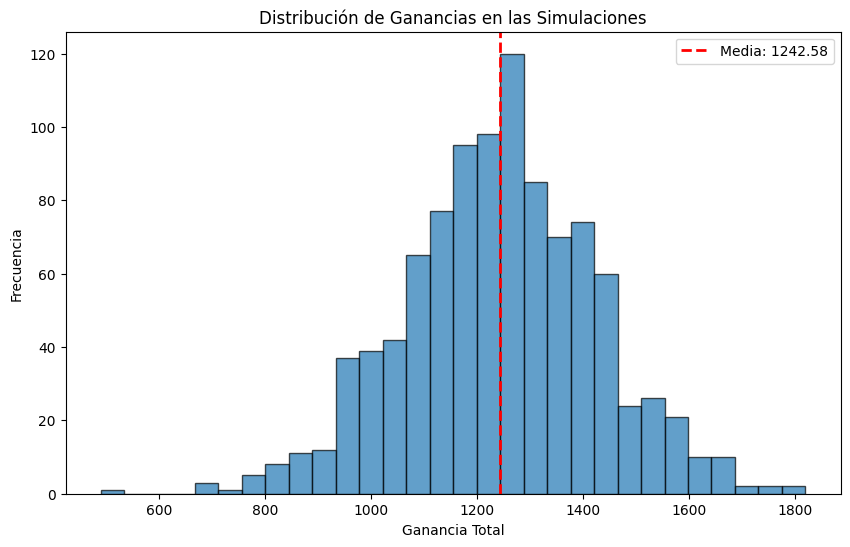

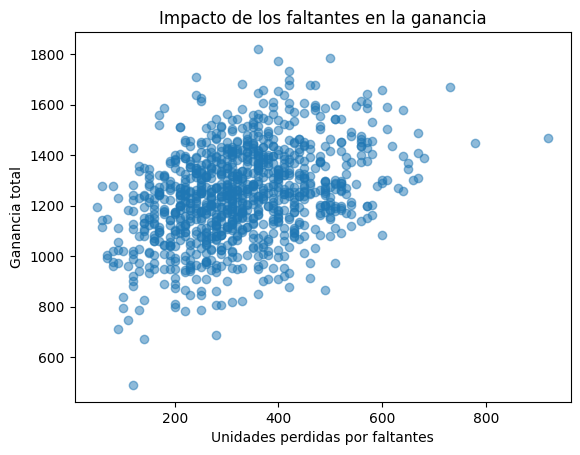

Ganancia promedio: 1242.58 ± 182.37
Faltantes: 327.01
5% peor caso: 947.22
Costo de órdenes: 495.49 (39.9% de ganancias)


In [72]:
# Configuración inicial
simulator_config = {
    'customer_arrival_function': customer_arrival_function,
    'customer_demand_function': customer_demand_function,
    'order_cost_function': order_cost_function,
    'products': [
        Product(initial_inventory=20, sell_prices=10, holding_cost=0.5, lead_time=2, s=5, S=20, demand_function=product_demand_function)
    ],
    'closing_time': 100
}

# Ejecutar 1000 simulaciones
results = run_multiple_simulations(InventoryKStockSimulator, n_simulations=1000, **simulator_config)

# Analizar resultados
stats = analyze_results(results)
print(f"Ganancia promedio: {stats['mean_profit']:.2f} ± {stats['std_profit']:.2f}")
print(f"Faltantes: {stats['mean_lost_sales']}")
print(f"5% peor caso: {np.percentile(results['profits'], 5):.2f}")
print(f"Costo de órdenes: {np.mean(results['order_costs']):.2f} ({(np.mean(results['order_costs']) / np.mean(results['profits'])) * 100:.1f}% de ganancias)")

In [74]:
# Definición de productos con características diversas
products_config = [
    {
        "name": "Producto A (Alta rotación)",
        "initial_inventory": 30,
        "sell_prices": 15,
        "holding_cost": 0.3,
        "lead_time": 1,
        "s": 10,
        "S": 40,
        "demand_function": lambda: np.random.poisson(8)
    },
    {
        "name": "Producto B (Bajo costo)",
        "initial_inventory": 50,
        "sell_prices": 8,
        "holding_cost": 0.1,
        "lead_time": 3,
        "s": 15,
        "S": 60,
        "demand_function": lambda: np.random.poisson(5)
    },
    {
        "name": "Producto C (Lujo)",
        "initial_inventory": 10,
        "sell_prices": 50,
        "holding_cost": 1.2,
        "lead_time": 2,
        "s": 3,
        "S": 25,
        "demand_function": lambda: np.random.poisson(2)
    }
]

In [82]:
def run_multi_product_simulation(config, n_simulations=500, closing_time=100):
    results = {
        'products': [],
        'total_profit': [],
        'total_holding_cost': [],
        'total_lost_sales': []
    }
    
    # Crear instancias de productos
    products = [
        Product(
            initial_inventory=p["initial_inventory"],
            sell_prices=p["sell_prices"],
            holding_cost=p["holding_cost"],
            lead_time=p["lead_time"],
            s=p["s"],
            S=p["S"],
            demand_function=p["demand_function"]
        ) for p in config
    ]
    
    # Configurar simulador
    simulator = InventoryKStockSimulator(
        customer_arrival_function=customer_arrival_function,
        customer_demand_function=customer_demand_function,
        order_cost_function=order_cost_function,
        products=products,
        closing_time=closing_time
    )
    
    for _ in tqdm(range(n_simulations)):
        # Ejecutar simulación
        products_results = simulator.simulate()
        
        # Almacenar resultados
        results['products'].append([p.summary() for p in products_results])
        results['total_profit'].append(sum(p.summary()['net profit'] for p in products_results))
        results['total_holding_cost'].append(sum(p.summary()['holding cost'] for p in products_results))
        results['total_lost_sales'].append(sum(p.summary()['lost amount'] for p in products_results))
    
    return results

In [84]:
def analyze_multi_product_results(results, products_config):
    # Métricas por producto
    product_names = [p["name"] for p in products_config]
    n_products = len(product_names)
    
    # Preparar datos
    profits_by_product = np.array([[r[i]['net profit'] for r in results['products']] for i in range(n_products)])
    holding_by_product = np.array([[r[i]['holding cost'] for r in results['products']] for i in range(n_products)])
    lost_by_product = np.array([[r[i]['lost amount'] for r in results['products']] for i in range(n_products)])

    # Gráfico de caja para ganancias por producto
    plt.figure(figsize=(12, 6))
    plt.boxplot(profits_by_product.T, labels=product_names)
    plt.title('Distribución de Ganancias por Producto')
    plt.ylabel('Ganancia ($)')
    plt.xticks(rotation=15)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Gráfico de barras apiladas (costos vs ganancias)
    mean_values = {
        'Ganancia': [np.mean(profits_by_product[i]) for i in range(n_products)],
        'Costo Inventario': [np.mean(holding_by_product[i]) for i in range(n_products)],
        'Pérdidas por Faltante': [np.mean(lost_by_product[i]) for i in range(n_products)]
    }

    fig, ax = plt.subplots(figsize=(12, 6))
    bottom = np.zeros(n_products)
    for metric, values in mean_values.items():
        ax.bar(product_names, values, label=metric, bottom=bottom)
        bottom += values
    ax.set_title('Desglose de Costos y Ganancias por Producto')
    ax.set_ylabel('Valor ($)')
    ax.legend()
    plt.xticks(rotation=15)
    plt.show()

    # Heatmap de correlación entre parámetros y resultados
    parameters = ['initial_inventory', 'sell_prices', 'holding_cost', 'lead_time', 's', 'S']
    metrics = ['net_profit', 'holding_cost', 'lost_amount']
    
    correlation_data = []
    for i, product in enumerate(products_config):
        row = [product[p] for p in parameters] + [
            np.mean(profits_by_product[i]),
            np.mean(holding_by_product[i]),
            np.mean(lost_by_product[i])
        ]
        correlation_data.append(row)
    
    # ... (código para heatmap de correlación)

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:08<00:00, 61.96it/s]


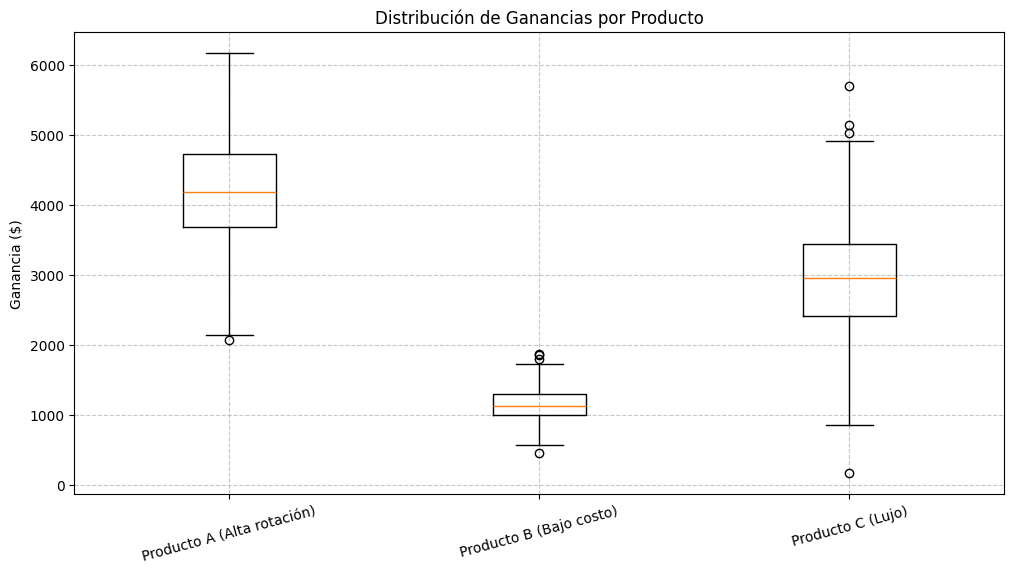

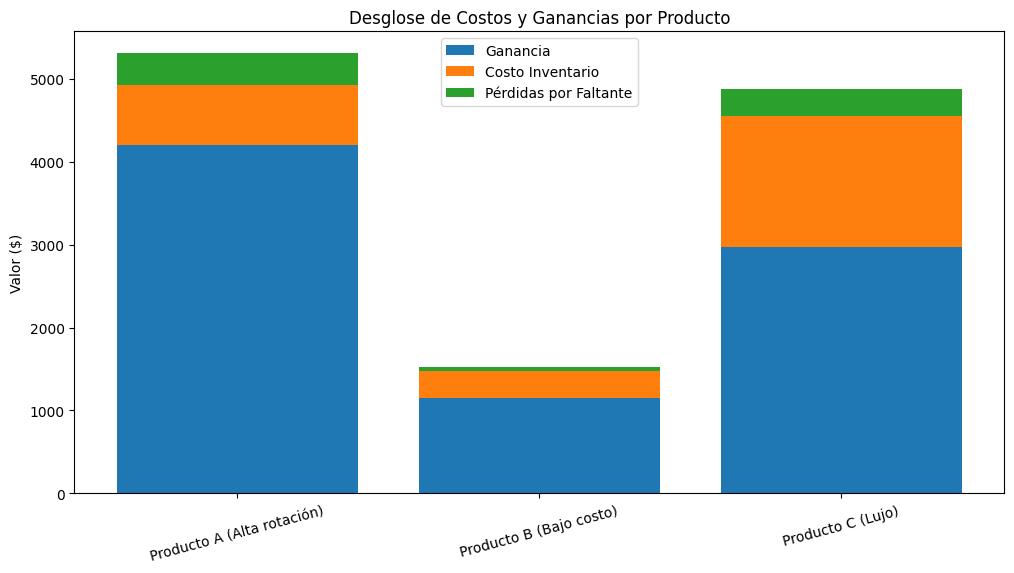


🔍 Producto A (Alta rotación):
   Ganancia promedio: $4200.23
   Costo inventario promedio: $723.48
   Pérdidas promedio por faltantes: 382.7 unidades

🔍 Producto B (Bajo costo):
   Ganancia promedio: $1149.93
   Costo inventario promedio: $329.60
   Pérdidas promedio por faltantes: 50.1 unidades

🔍 Producto C (Lujo):
   Ganancia promedio: $2975.26
   Costo inventario promedio: $1574.49
   Pérdidas promedio por faltantes: 326.1 unidades


In [85]:
# Ejecutar simulaciones
results = run_multi_product_simulation(products_config, n_simulations=500)

# Analizar resultados
analyze_multi_product_results(results, products_config)

# Resultados numéricos clave
for i, product in enumerate(products_config):
    print(f"\n🔍 {product['name']}:")
    print(f"   Ganancia promedio: ${np.mean([r[i]['net profit'] for r in results['products']]):.2f}")
    print(f"   Costo inventario promedio: ${np.mean([r[i]['holding cost'] for r in results['products']]):.2f}")
    print(f"   Pérdidas promedio por faltantes: {np.mean([r[i]['lost amount'] for r in results['products']]):.1f} unidades")

100%|██████████| 100/100 [00:01<00:00, 73.22it/s]


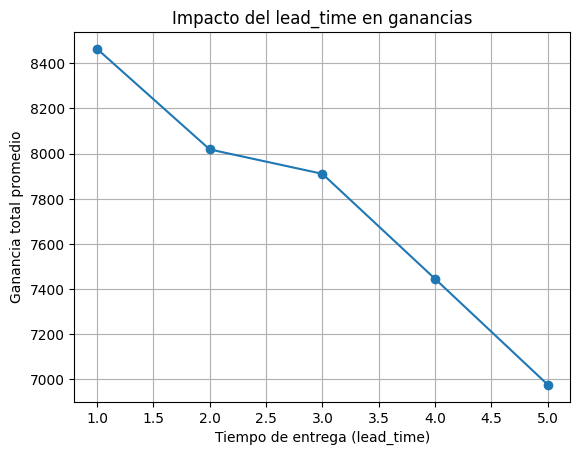

In [86]:
lead_times = range(1, 6)
profits_vs_leadtime = []

for lt in lead_times:
    modified_config = [dict(p) for p in products_config]  # Copia profunda
    for p in modified_config:
        p["lead_time"] = lt
    
    results = run_multi_product_simulation(modified_config, n_simulations=100)
    profits_vs_leadtime.append(np.mean(results['total_profit']))

plt.plot(lead_times, profits_vs_leadtime, marker='o')
plt.xlabel('Tiempo de entrega (lead_time)')
plt.ylabel('Ganancia total promedio')
plt.title('Impacto del lead_time en ganancias')
plt.grid()
plt.show()

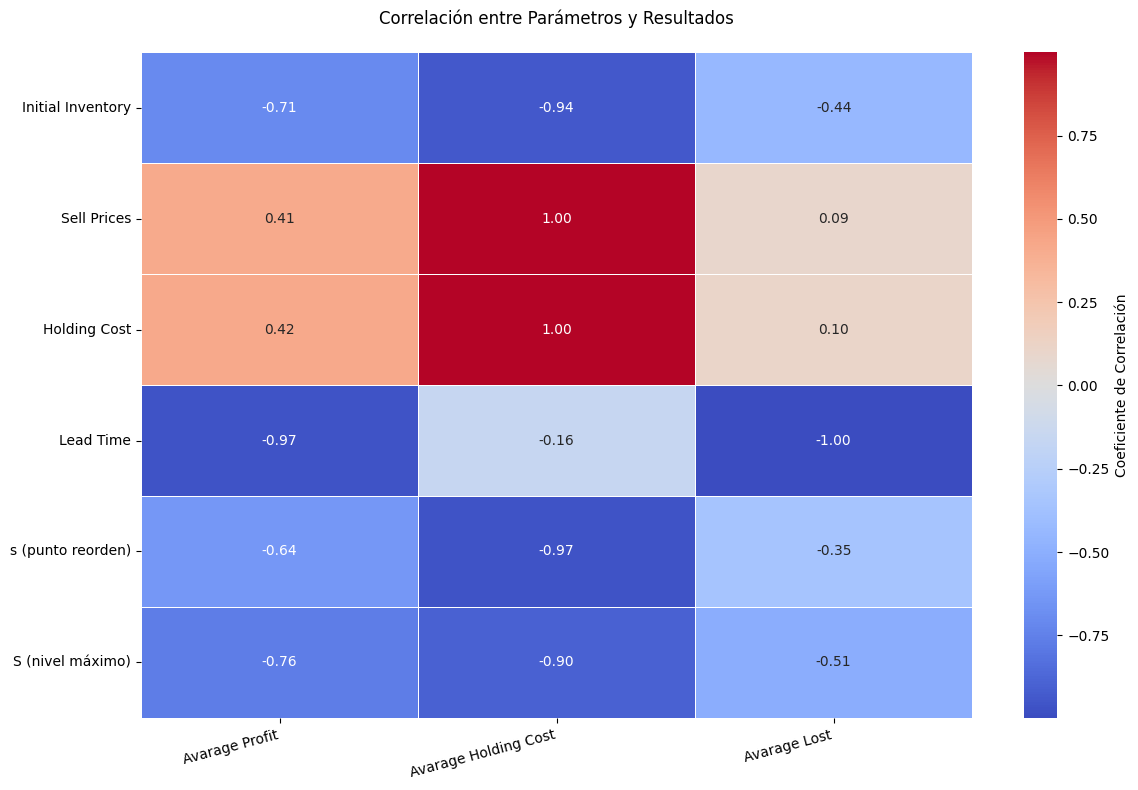

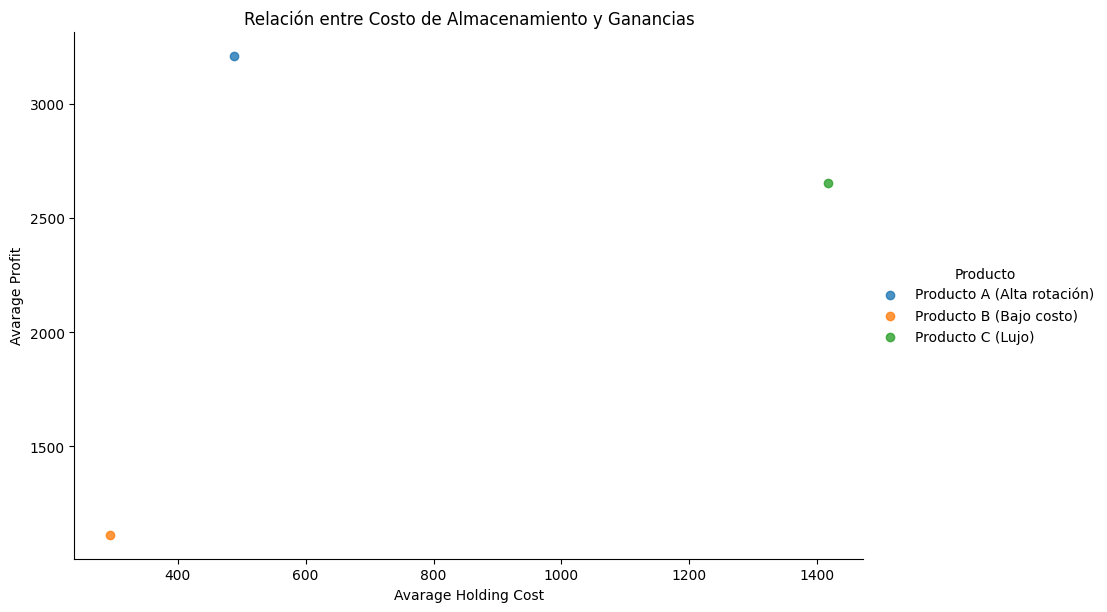

In [94]:
import pandas as pd
import seaborn as sns

def plot_correlation_heatmap(results, products_config):
    # Preparar los datos en un DataFrame
    data = []
    
    for i, product in enumerate(products_config):
        # Obtener métricas promedio para este producto
        avg_profit = np.mean([r[i]['net profit'] for r in results['products']])
        avg_holding = np.mean([r[i]['holding cost'] for r in results['products']])
        avg_lost = np.mean([r[i]['lost amount'] for r in results['products']])
        
        # Crear fila de datos
        row = {
            'Producto': product['name'],
            'Initial Inventory': product['initial_inventory'],
            'Sell Prices': product['sell_prices'],
            'Holding Cost': product['holding_cost'],
            'Lead Time': product['lead_time'],
            's (punto reorden)': product['s'],
            'S (nivel máximo)': product['S'],
            'Avarage Demand': product['demand_function'](),  # Una muestra de la demanda
            'Avarage Profit': avg_profit,
            'Avarage Holding Cost': avg_holding,
            'Avarage Lost': avg_lost
        }
        data.append(row)
    
    df = pd.DataFrame(data)
    
    # Calcular matriz de correlación
    numeric_cols = [
        'Initial Inventory', 'Sell Prices', 'Holding Cost', 
        'Lead Time', 's (punto reorden)', 'S (nivel máximo)',
        'Avarage Profit', 'Avarage Holding Cost', 'Avarage Lost'
    ]
    corr_matrix = df[numeric_cols].corr()
    
    # Filtrar solo las correlaciones con las métricas de resultado
    target_metrics = ['Avarage Profit', 'Avarage Holding Cost', 'Avarage Lost']
    corr_matrix = corr_matrix.loc[numeric_cols[:-3], target_metrics]
    
    # Crear heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap='coolwarm', 
        center=0,
        fmt=".2f",
        linewidths=0.5,
        annot_kws={"size": 10},
        cbar_kws={'label': 'Coeficiente de Correlación'}
    )
    plt.title('Correlación entre Parámetros y Resultados', pad=20)
    plt.xticks(rotation=15, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    sns.lmplot(
        data=df,
        x='Avarage Holding Cost',
        y='Avarage Profit',
        hue='Producto',
        height=6,
        aspect=1.5
        )
    plt.title('Relación entre Costo de Almacenamiento y Ganancias')
    plt.show()
    
    return df

# Ejecutar la función con los resultados
df_results = plot_correlation_heatmap(results, products_config)